# CIR Model Results 
---
This notebook presents the results of a generator trained on the **CIR model**.

---
Google Colab case

If you run this notebook on Google Colab, the utils folder is not available by default.
You must therefore download the utils.zip file provided with this notebook and then run the next cell, which extracts the archive and makes the utils folder accessible to Python.

Local case

If you already have the utils folder in the correct location, or if your environment is properly configured,
you can leave the next cell as is, or simply keep it commented.

In [ ]:
import os

BASE = "/content"
os.chdir(BASE)
print("Working directory:", os.getcwd())

# If utils directory does not exist, unzip it
if not os.path.isdir(os.path.join(BASE, "utils")):
    !unzip "utils.zip" -d /content


In [2]:
import torch
import torch.nn as nn

__dtype__ = torch.float32
__device__ = torch.device('cuda:0')

print("GPU available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
    print("CUDA (PyTorch) :", torch.version.cuda)
    print("cuDNN :", torch.backends.cudnn.version())

!nvidia-smi

GPU available : True
GPU : Tesla V100-SXM2-32GB
CUDA (PyTorch) : 12.1
cuDNN : 8902
Tue Jan 13 13:59:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.51.03              Driver Version: 575.51.03      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-SXM2-32GB           Off |   00000000:18:00.0 Off |                    0 |
| N/A   46C    P0             59W /  300W |    1586MiB /  32768MiB |      0%      Default |
|                                         |              

$$
\textbf{Neural Network Generator}
$$

---

### **Overview**

The **`Generator`** class defines a **neural network-based generative model** designed to produce synthetic samples conditioned on **stochastic noise** and **input parameters**.

This generator maps **random noise** and **model parameters** to **a single output value**, effectively learning to generate a distribution that mimics a target process.

---

### **Architecture**
The generator follows a **feedforward neural network** structure:
1. **Inputs**:  
   - **Noise vector** of size **`noise_size`** (random component).  
   - **Model parameters** of size **`param_size`** (conditioning information).  
2. **Feature Transformations**:  
   - The noise and parameter inputs are **independently projected** to higher dimensions using linear layers:  
     - Noise is mapped to **`noise_dim`**.  
     - Parameters are mapped to **`param_dim_G`**.  
   - The transformed features are concatenated.
3. **Feedforward Layers**:  
   - The concatenated features pass through **`nb_hidden_layers_G`** hidden layers, each with **`hidden_dim_G`** neurons.  
   - Each layer applies:  
     - A **linear transformation**.  
     - A **Softplus activation** function for smooth non-linearity.
4. **Output Layer**:  
   - A final linear layer produces **a single output**.  
   - The final activation function is **Identity**, meaning no transformation is applied to the output.

### **Network representation**

$$
\begin{array}{ccc}
\textbf{Noise Input} & & \textbf{Parameter Input} \\
(\text{size} = \text{noise\_size}) & & (\text{size} = \text{param\_size}) \\
\downarrow & & \downarrow \\
\text{Linear Layer} & & \text{Linear Layer} \\
(\text{noise\_size} \to \text{noise\_dim}) & & (\text{param\_size} \to \text{param\_dim}) \\
\searrow & & \swarrow \\
\end{array}
$$

$$
\begin{array}{c}
\textbf{Concatenation} \\
\downarrow \\
\text{Linear Layer + Softplus} \quad ( \text{noise\_dim + param\_dim} \to \text{hidden\_dim}) \\
\downarrow \\
\text{Hidden Layers + Softplus} \quad (\text{hidden\_dim} \to \text{hidden\_dim}) \\
\downarrow \\
\textbf{Final Linear Layer} \quad (\text{hidden\_dim} \to 1) \\
\downarrow \\
\textbf{Output (Single Generated Value)}
\end{array}
$$


In [3]:
class Generator(nn.Module):
    def __init__(self,
                 noise_size: int=1,  # Size of the noise input
                 param_size: int=1,  # Size of the parameter input
                 noise_dim: int=50,  # Dimension after transforming noise input
                 param_dim_G: int=100,  # Dimension after transforming parameter input
                 hidden_dim_G: int=100,  # Number of neurons in hidden layers
                 nb_hidden_layers_G: int=1,  # Number of hidden layers
                 **kwargs):
        super(Generator, self).__init__()
        
        # Store model hyperparameters
        self.noise_size = noise_size
        self.param_size = param_size
        self.noise_dim = noise_dim
        self.param_dim = param_dim_G
        self.nb_hidden_layers = nb_hidden_layers_G
        self.hidden_dim = hidden_dim_G
        
        # Activation function (Softplus for smooth non-linearity)
        self.activation = torch.nn.Softplus(beta=10., threshold=20.0)
        
        # Linear transformations for noise and parameter inputs
        self.input_noise = nn.Linear(self.noise_size, self.noise_dim)
        self.input_param = nn.Linear(self.param_size, self.param_dim)
        
        # List to store hidden layers
        self.fcs = nn.ModuleList()
        for i in range(self.nb_hidden_layers):
            if i == 0:
                # First hidden layer connects transformed noise & parameter inputs
                self.fcs.append(nn.Linear(self.noise_dim + self.param_dim, self.hidden_dim))
            else:
                # Subsequent hidden layers
                self.fcs.append(nn.Linear(self.hidden_dim, self.hidden_dim))
        
        # Output layer (single neuron output)
        self.fcs.append(nn.Linear(self.hidden_dim, 1))
        
        # Final activation (Identity, meaning no transformation at output)
        self.final_activation = torch.nn.Identity()
        
        # Create the sequential model
        self.make_sequential()
    
    def make_sequential(self):
        """
        Constructs a sequential model from the list of layers and activations.
        """
        layers = []
        for i in range(self.nb_hidden_layers):
            layers.append(self.fcs[i])
            layers.append(self.activation)  # Apply activation after each hidden layer
        layers.append(self.fcs[-1])  # Final output layer
        layers.append(self.final_activation)  # No activation at the output
        
        self.M = nn.Sequential(*layers)
    
    def forward(self, x):
        """
        Forward pass of the generator.
        :param x: Input tensor containing both noise and parameters.
        :return: Generated output.
        """
        
        # Process noise and parameter inputs separately
        noise = self.input_noise(x[:, :self.noise_size])
        params = self.input_param(x[:, self.noise_size:])
        
        # Concatenate processed noise and parameter inputs
        x = torch.cat((noise, params), dim=1)
        
        # Pass through the sequential network
        return self.M(self.activation(x))



$$\textbf{Loading a Generator Model from a Checkpoint}$$

---

### **Overview**

The function **`load_generator_from_dir(dir_model)`** restores a previously trained **Generator** model by:
- Loading the model saved in dir_model.
- Extracting the required layer dimensions from the saved weights.
- Creating a new instance of the Generator with the extracted dimensions.
- Restoring the model's weights.


### **Visual Representation**

\begin{array}{c}
\text{Load Checkpoint} \\
\downarrow \\
\text{Extract Dimensions} \\
\downarrow \\
\text{Instantiate Generator Model} \\
\downarrow \\
\text{Load Weights} \\
\downarrow \\
\textbf{Generator Model Ready}
\end{array}



In [4]:
def load_generator_from_dir(dir_model):
    """
    Loads a Generator model from a saved model, extracting the necessary dimensions and restoring weights.
    :param dir_model: Path to the saved model.
    :return: A Generator model with the loaded weights.
    """
    
    # Load the checkpoint file
    state_dict = torch.load(dir_model, map_location=torch.device('cpu'))
    
    # Extract layer dimensions from the state_dict
    noise_size = state_dict['input_noise.weight'].shape[1]  # Size of the noise input
    param_size = state_dict['input_param.weight'].shape[1]  # Size of the parameter input
    noise_dim = state_dict['input_noise.weight'].shape[0]   # Projected size of noise input
    param_dim_G = state_dict['input_param.weight'].shape[0] # Projected size of parameter input
    hidden_dim_G = state_dict['fcs.0.weight'].shape[0]      # Hidden layer size
    nb_hidden_layers_G = (len([k for k in state_dict.keys() if 'fcs' in k]) - 1) // 2  # Number of hidden layers
    
    # Print extracted dimensions
    print(f"Noise size (input): {noise_size}")
    print(f"Param size (input): {param_size}")
    print(f"Noise dim (hidden): {noise_dim}")
    print(f"Param dim (hidden): {param_dim_G}")
    print(f"Hidden dim: {hidden_dim_G}")
    print(f"Number of hidden layers: {nb_hidden_layers_G}")
    
    # Create a new instance of the model with the extracted dimensions
    model = Generator(
        noise_size=noise_size,
        param_size=param_size,
        noise_dim=noise_dim,
        param_dim_G=param_dim_G,
        hidden_dim_G=hidden_dim_G,
        nb_hidden_layers_G=nb_hidden_layers_G
    )
    
    # Load the saved state_dict into the model
    model.load_state_dict(state_dict)
    
    return model

$$
\textbf{CIR\_param: A Parameterized Dataset Class for the CIR Variance Process}
$$

---

### **Overview**

The **`CIR_param`** class generates **parameter samples** for the **Cox–Ingersoll–Ross (CIR) variance process**, which constitutes the variance component of the Heston stochastic volatility model.

It supports two operating modes:
- **Random sampling**: parameters are drawn from continuous distributions subject to admissibility constraints.
- **Deterministic mode**: parameters are provided as discrete grids and all possible **Cartesian combinations** are generated.

This class is purely **parametric** and does **not** perform any stochastic simulation.

---

### **How Parameter Generation Works**

#### **🔹 Random Sampling Mode**

In random mode, each parameter is specified as a pair

$$
[\text{param}_{\min}, \text{param}_{\max}],
$$

from which samples are drawn uniformly:

$$
X_{\text{sample}} \sim \mathcal{U}(\text{param}_{\min}, \text{param}_{\max}).
$$

This applies to the CIR parameters:
- mean reversion speed $\kappa$,
- long-term variance level $\bar v$,
- volatility of volatility $\gamma$,
- initial variance $v_0$,
- time horizon $T$.

If a parameter is provided as a singleton list $[\text{value}]$, the same value is reused for all samples.

---

#### **Constraint on $\gamma$ (Volatility of Volatility)**

To ensure numerical stability and non-degenerate variance dynamics, the CIR process is sampled under a **Feller-type constraint**:

$$
\frac{1}{6} < \frac{2\,\kappa\,\bar v}{\gamma^2} < 10.
$$

This induces admissible bounds for $\gamma$ given $(\kappa,\bar v)$:

$$
\Gamma_{\text{floor}} = \sqrt{\frac{\kappa\,\bar v}{5}},
\qquad
\Gamma_{\text{cap}} = \min\!\left(\sqrt{12\,\kappa\,\bar v},\;\Gamma_{\max}\right).
$$

The volatility-of-volatility parameter is then sampled as

$$
\gamma_{\text{sample}} \sim \mathcal{U}\big(\Gamma_{\text{floor}},\,\Gamma_{\text{cap}}\big).
$$

This guarantees that the CIR variance process remains well-behaved over the sampled parameter space.

---

#### **🔹 Deterministic Mode (Cartesian Product)**

In deterministic mode, each parameter is provided as a finite list of admissible values:

$$
[\text{param}_1,\,\text{param}_2,\,\dots,\,\text{param}_n].
$$

The dataset is constructed by taking the **Cartesian product** of all parameter lists:

$$
\text{params}
=
\text{Cartesian\_Product}(\kappa,\,\gamma,\,\bar v,\,v_0,\,T).
$$

This guarantees that every possible parameter combination is included exactly once.

---

### **Workflow Summary**

$$
\begin{array}{c}
\text{Initialize Dataset} \\
\downarrow \\
\text{Convert Parameter Ranges to Tensors} \\
\downarrow \\
\textbf{If Random Sampling:} \\
\quad \text{Sample Parameters Uniformly} \\
\quad \text{Apply Feller Constraint on }\gamma \\
\quad \text{Stack Parameters into a Tensor} \\
\textbf{Else:} \\
\quad \text{Generate Cartesian Product of Parameters} \\
\downarrow \\
\text{Dataset Ready}
\end{array}
$$

---

### **⚠️ Important Warning**

> 🚨 **This class does NOT simulate the CIR or Heston processes.**  
> It only generates and stores **admissible parameter configurations**.  
> The stochastic simulation of the CIR variance or the full Heston model is implemented separately and consumes these parameters as input.


In [5]:
from torch.utils.data import Dataset

class CIR_param(Dataset):
    def __init__(self,
                 dtype,
                 device: torch.device = torch.device('cuda:0'),
                 log_model: bool = True,
                 random_param: bool = False,
                 KAPPAS: object = [1.],
                 GAMMAS: object = [0.1, 1.0],  # explicit gamma bounds
                 VBARS: object = [1.],
                 v0: object = [1.],
                 T: object = [1.],
                 nb_simu: int = 100,
                 feller_ratio: list = [0.15, 10.0],
                 **kwargs):
        self.dtype = dtype
        self.device = device
        self.random_param = random_param
        self.KAPPAS = KAPPAS
        self.GAMMAS = GAMMAS
        self.VBARS = VBARS
        self.v0 = v0
        self.T = T
        self.nb_simu = nb_simu
        self.feller_ratio = feller_ratio
        self.make_params()

    def __len__(self):
        return self.nb_simu

    def __getitem__(self, index):
        return self.params[index]

    def make_params(self):
        self.KAPPAS_torch = torch.tensor(self.KAPPAS, dtype=self.dtype, device=self.device)
        self.GAMMAS_torch = torch.tensor(self.GAMMAS, dtype=self.dtype, device=self.device)
        self.VBARS_torch = torch.tensor(self.VBARS, dtype=self.dtype, device=self.device)
        self.v0_torch = torch.tensor(self.v0, dtype=self.dtype, device=self.device)
        self.T_torch = torch.tensor(self.T, dtype=self.dtype, device=self.device)

        if self.random_param:
            self.KAPPAS_sample = self._sample_param(self.KAPPAS_torch, self.nb_simu)
            self.VBARS_sample = self._sample_param(self.VBARS_torch, self.nb_simu)

            # Feller bounds
            feller_min, feller_max = self.feller_ratio
            gamma_min_feller = torch.sqrt(2 * self.KAPPAS_sample * self.VBARS_sample / feller_max)
            gamma_max_feller = torch.sqrt(2 * self.KAPPAS_sample * self.VBARS_sample / feller_min)

            # Explicit bounds from GAMMAS input
            gamma_min_input = self.GAMMAS_torch[0]
            gamma_max_input = self.GAMMAS_torch[-1]

            # Final intersection of both constraints
            gamma_floor = torch.clamp(gamma_min_feller, min=gamma_min_input)
            gamma_cap = torch.clamp(gamma_max_feller, max=gamma_max_input)

            self.GAMMAS_sample = gamma_floor + torch.rand(self.nb_simu, device=self.device) * (gamma_cap - gamma_floor)

            self.v0_sample = self._sample_param(self.v0_torch, self.nb_simu)
            self.T_sample = self._sample_param(self.T_torch, self.nb_simu)

            self.params_stack = torch.stack((self.KAPPAS_sample, self.GAMMAS_sample, self.VBARS_sample,
                                              self.v0_sample, self.T_sample))
            self.params = self.params_stack.T
        else:
            self.params = torch.cartesian_prod(self.KAPPAS_torch, self.GAMMAS_torch, self.VBARS_torch,
                                                self.v0_torch, self.T_torch)
            self.nb_simu = len(self.params)

    def _sample_param(self, param_tensor, nb):
        return param_tensor.repeat(nb) if len(param_tensor) == 1 \
               else torch.distributions.Uniform(param_tensor[0], param_tensor[-1]).sample((nb,))


### Exact simulation of the CIR process

The function `CIR` simulates the **terminal value of the Cox–Ingersoll–Ross (CIR) variance process** at time $T$ using an **exact transition scheme**.

The CIR dynamics are given by

$$
dV_t = \kappa(\bar v - V_t)\,dt + \gamma \sqrt{V_t}\,dW_t,
$$

where $\kappa > 0$ is the mean-reversion speed, $\bar v > 0$ the long-term variance level, $\gamma > 0$ the volatility of volatility, and $V_0 = v_0$ the initial variance.

---

### Exact transition at time $T$

The CIR process admits an explicit marginal distribution. Conditionally on $V_0$, the terminal variance $V_T$ can be written as

$$
V_T = c \, \chi^2_{\nu + 2N},
$$

where:
- $\chi^2_{\nu + 2N}$ is a chi-square random variable,
- $N$ is a Poisson random variable,
- the degrees of freedom and scaling constants are given by

$$
\nu = \frac{4\kappa \bar v}{\gamma^2}, \qquad
\lambda = \frac{4\kappa e^{-\kappa T}}{\gamma^2(1 - e^{-\kappa T})} \, v_0,
$$

$$
c = \frac{\gamma^2(1 - e^{-\kappa T})}{4\kappa}.
$$

The Poisson variable $N$ is sampled as

$$
N \sim \text{Poisson}\!\left(\tfrac{\lambda}{2}\right),
$$

and the final variance is obtained by scaling the chi-square draw.

This construction corresponds to the **exact marginal simulation** of the CIR process and avoids any time discretization error.

---

### Numerical safeguards

After sampling, the terminal variance is optionally clipped to a fixed interval

$$
V_T \in [\sigma_{\min},\,\sigma_{\max}],
$$

to prevent numerical instabilities in downstream applications.

---

### Output

The function returns a tensor of size $N_{\text{traj}}$ containing independent samples of the terminal variance $V_T$, each corresponding to its own parameter set $(\kappa, \gamma, \bar v, v_0, T)$.

This exact CIR sampler is used both as a benchmark for validation and as a building block in more complex stochastic volatility models such as Heston.


In [6]:
def CIR(kappa, gamma, vbar, v0, T,
              dtype=torch.float32, device=torch.device('cuda'),
              sigma_min=1e-7, sigma_max=5.0):
    """
    Simulate final values v_T for the CIR process using the exact transition
    (Broadie & Kaya) in one shot.

    Args:
        kappa: Mean reversion speed (tensor [N_traj])
        gamma: Vol of vol (tensor [N_traj])
        vbar: Long-term mean (tensor [N_traj])
        v0: Initial variance (tensor [N_traj])
        T: Horizon (tensor [N_traj])
        sigma_min, sigma_max: Clipping bounds for the output variance

    Returns:
        v_T: final variance at T (tensor [N_traj])
    """
    N_traj = T.shape[0]

    # Compute transition constants
    d = 4 * kappa * vbar / gamma**2
    l = 4 * kappa * torch.exp(-kappa * T) / (gamma**2 * (1 - torch.exp(-kappa * T)))
    c = gamma**2 * (1 - torch.exp(-kappa * T)) / (4 * kappa)

    # Poisson parameter lambda
    lda = l * v0

    # Draw Poisson and Chi2
    Poisson = torch.poisson(lda / 2)
    chi2 = torch.distributions.chi2.Chi2(d + 2 * Poisson).sample()

    # Exact CIR marginal
    v_T = c * chi2

    # Optional clipping
    v_T = torch.clamp(v_T, min=sigma_min, max=sigma_max)

    return v_T


### Marginal distribution comparison

The function `show_marginal` compares the marginal distributions produced by a generative model with the true target distribution for a given set of parameters.

For each parameter vector in the dataset, the function generates a large number of samples using:
- the true model,
- the learned generator.

To improve visual readability, samples are clipped symmetrically using an upper quantile threshold.

Let $X^{\text{true}}$ and $X^{\text{model}}$ denote the true and generated samples, respectively.  
The comparison is quantified using the 1-Wasserstein distance

$$
W_1(X^{\text{true}}, X^{\text{model}})
$$

which measures the discrepancy between the two marginal distributions.

#### Procedure

1. Generate $N_{\text{traj}}$ true samples for the given parameters.
2. Generate $N_{\text{traj}}$ samples from the model using random noise.
3. Clip both samples to a common quantile range to remove extreme tails.
4. Estimate and plot the kernel density of both distributions.
5. Compute and report the Wasserstein distance.
6. Optionally save the resulting figure.

#### Output

For each parameter set, the function displays a density comparison plot and prints the corresponding Wasserstein distance, providing a direct visual and quantitative assessment of marginal accuracy.


In [7]:
def show_marginal(model, dataset, N_traj=50000, noise_size=5, 
                  cap=5, dtype=torch.float32, device=torch.device('cuda'),
                  save_fig_dir=""):
    """
    Display the marginal distributions for the generated samples from the model and compare them
    to the true CIR distribution using the Wasserstein distance, with optional capping and positive domain.
    """

    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy.stats import wasserstein_distance
    import numpy as np
    import os

    if save_fig_dir:
        os.makedirs(save_fig_dir, exist_ok=True)

    for i, param in enumerate(dataset):
        input_param = param.expand(N_traj, -1).T
        true_sample = CIR(*input_param, dtype=dtype, device=device)

        # ✅ Cap extrême pour stabilité numérique
        relevant_index = torch.where((true_sample > 0) & (true_sample < cap))
        true_sample = true_sample[relevant_index].to('cpu')

        # GAN sample
        uniform = torch.rand(N_traj, noise_size, device=device)
        INPUT_GAN = torch.cat((uniform, param.unsqueeze(0).repeat((N_traj, 1))), dim=1)
        model_sample = model(INPUT_GAN).detach().view(-1).cpu()

        # ✅ Cap aussi le GAN sur les positifs
        model_sample = model_sample[(model_sample > 0) & (model_sample < cap)]

        # Wasserstein distance
        W = wasserstein_distance(true_sample.numpy(), model_sample.numpy())

        print(f"\n📌 Parameter set {i}")
        print(f"    κ = {param[0].item():.3f}   γ = {param[1].item():.3f}   v̄ = {param[2].item():.3f}    ν0 = {param[3].item():.3f}   T = {param[4].item():.3f}")
        print(f"    📏 Wasserstein distance: {W:.4f}")

        # === Plot ===
        fig, ax = plt.subplots(figsize=(9, 4.5))

        sns.kdeplot(true_sample.numpy(), color='navy', lw=2, label='True CIR', alpha=0.8, ax=ax)
        sns.kdeplot(model_sample.numpy(), color='crimson', lw=2, label='GAN', linestyle='--', alpha=0.8, ax=ax)

        ax.set_xlim(left=0)  # ✅ Forcer axe des x >= 0
        ax.set_title(f"Marginal Distribution Comparison (Parameter set {i+1})", fontsize=14, weight="bold")
        ax.set_xlabel("Sample Value", fontsize=12)
        ax.set_ylabel("Density", fontsize=12)
        ax.legend(loc="upper right")
        ax.grid(True, linestyle='--', alpha=0.5)

        # Save figure if requested
        if save_fig_dir:
            κ, γ, v̄, ν0, T_val = param.tolist()
            filename = f"heston_set{i}_kappa{κ:.2f}_gamma{γ:.2f}_vbar{v̄:.2f}_nu0{ν0:.2f}_T{T_val:.2f}.png"
            filename = filename.replace(" ", "").replace(":", "")
            save_path = os.path.join(save_fig_dir, filename)
            plt.savefig(save_path, dpi=300)
            print(f"📸 Figure saved to: {save_path}")

        plt.tight_layout()
        plt.show()


$$
\textbf{Load the models}
$$


In [8]:
# load model with all parameters
dir_model = 'utils/models/CIR_model(GAN).pt' # directory containing the model
model = load_generator_from_dir(dir_model)  # rebuild the model
model.to(__device__) 
model.eval() 

Noise size (input): 5
Param size (input): 5
Noise dim (hidden): 150
Param dim (hidden): 150
Hidden dim: 300
Number of hidden layers: 3


Generator(
  (activation): Softplus(beta=10.0, threshold=20.0)
  (input_noise): Linear(in_features=5, out_features=150, bias=True)
  (input_param): Linear(in_features=5, out_features=150, bias=True)
  (fcs): ModuleList(
    (0-2): 3 x Linear(in_features=300, out_features=300, bias=True)
    (3): Linear(in_features=300, out_features=1, bias=True)
  )
  (final_activation): Identity()
  (M): Sequential(
    (0): Linear(in_features=300, out_features=300, bias=True)
    (1): Softplus(beta=10.0, threshold=20.0)
    (2): Linear(in_features=300, out_features=300, bias=True)
    (3): Softplus(beta=10.0, threshold=20.0)
    (4): Linear(in_features=300, out_features=300, bias=True)
    (5): Softplus(beta=10.0, threshold=20.0)
    (6): Linear(in_features=300, out_features=1, bias=True)
    (7): Identity()
  )
)

### Typical parameter testing for the CIR model

This experiment evaluates the generator on representative, market-consistent CIR parameter configurations.

The typical parameter sets are chosen within the training domain and correspond to calibrated regimes commonly encountered in equity option markets. The training ranges are defined as

$$
\kappa \in [0.5,\,4.0], \qquad
\bar v \in [0.01,\,0.15], \qquad
v_0 \in [0.01,\,0.1],
$$

and

$$
\gamma \in \Big[
\max\!\big(\sqrt{\kappa \bar v / 5},\,0.1\big),\;
\min\!\big(\sqrt{12\,\kappa \bar v},\,0.8\big)
\Big].
$$

This parametrization guarantees that the Feller ratio satisfies

$$
\frac{2\kappa \bar v}{\gamma^2} \;\in\; \Big[\tfrac{1}{6},\,10\Big],
$$

ensuring non-degenerate variance dynamics while allowing for both weak and strong mean reversion regimes.

The maturities are selected in the range

$$
T \in \left[\tfrac{90}{365},\,\tfrac{365}{365}\right].
$$

The selected configurations are strictly in-domain and are used to assess the accuracy of the learned generator under typical calibrated market conditions, rather than stress or extrapolation scenarios.


Sample 1: Feller ratio ≈ 0.26
Sample 2: Feller ratio ≈ 0.53
Sample 3: Feller ratio ≈ 0.45
Sample 4: Feller ratio ≈ 1.03
Sample 5: Feller ratio ≈ 0.81
Sample 6: Feller ratio ≈ 7.72

📌 Parameter set 0
    κ = 0.820   γ = 0.620   v̄ = 0.030    ν0 = 0.010   T = 1.000
    📏 Wasserstein distance: 0.0031


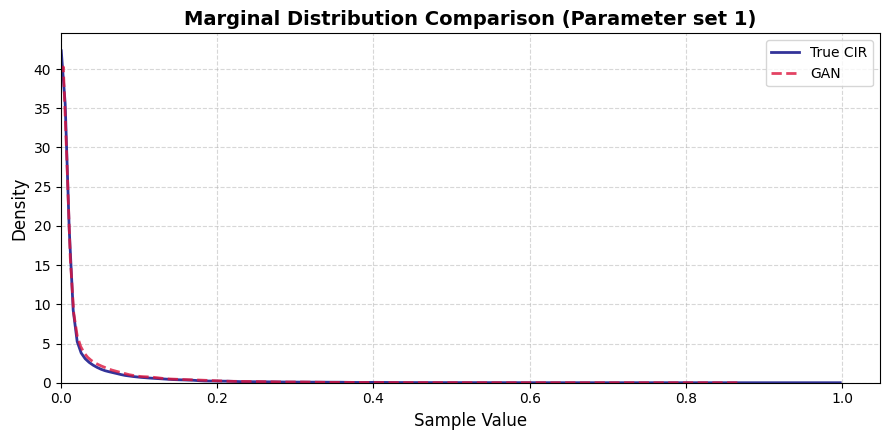


📌 Parameter set 1
    κ = 1.150   γ = 0.590   v̄ = 0.040    ν0 = 0.020   T = 1.000
    📏 Wasserstein distance: 0.0027


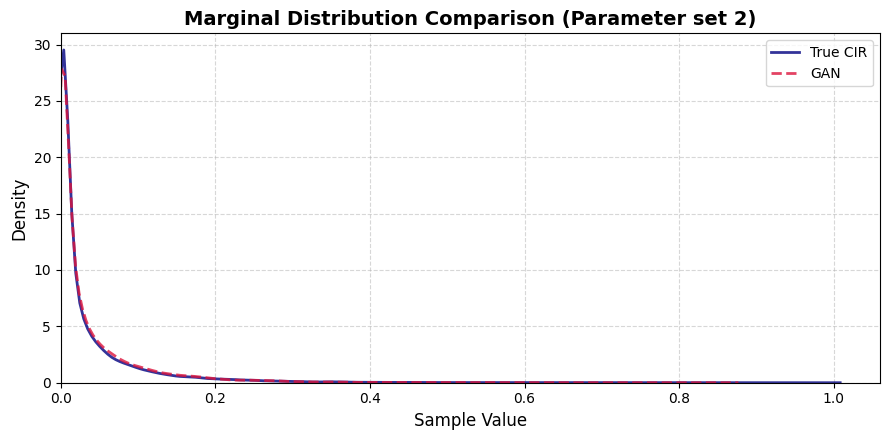


📌 Parameter set 2
    κ = 0.910   γ = 0.900   v̄ = 0.100    ν0 = 0.040   T = 0.250
    📏 Wasserstein distance: 0.0024


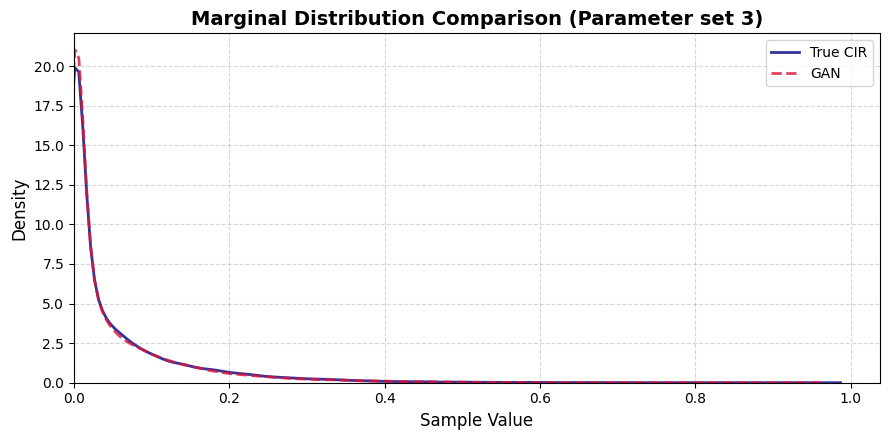


📌 Parameter set 3
    κ = 3.860   γ = 0.950   v̄ = 0.060    ν0 = 0.060   T = 1.000
    📏 Wasserstein distance: 0.0039


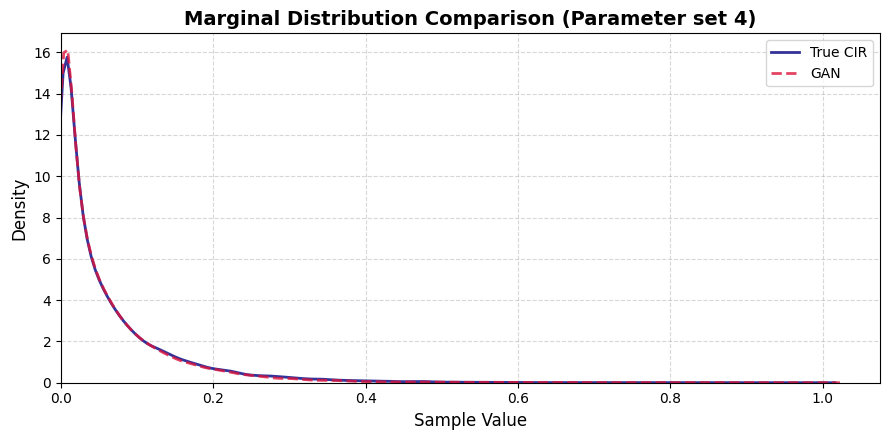


📌 Parameter set 4
    κ = 0.800   γ = 0.690   v̄ = 0.120    ν0 = 0.080   T = 0.250
    📏 Wasserstein distance: 0.0024


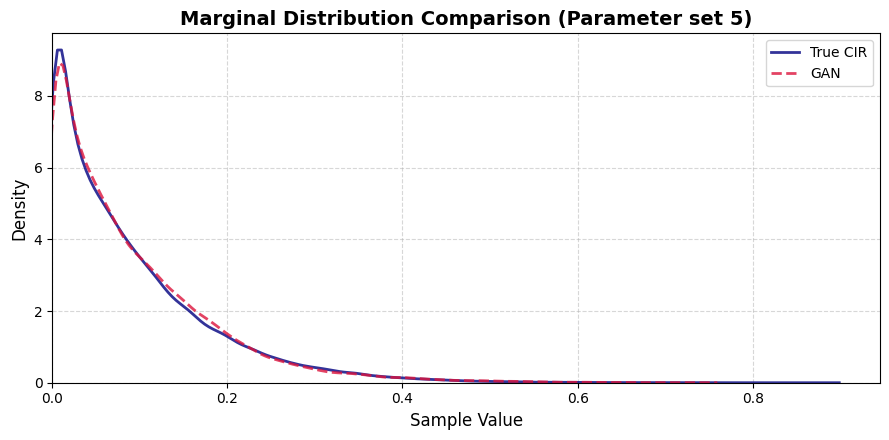


📌 Parameter set 5
    κ = 3.860   γ = 0.400   v̄ = 0.080    ν0 = 0.100   T = 1.000
    📏 Wasserstein distance: 0.0012


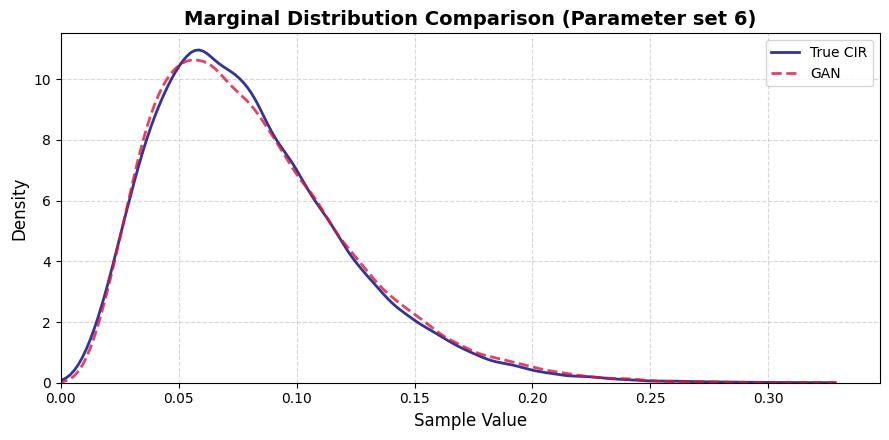

In [9]:
import torch

# Heston parameters: edge cases with violated Feller condition (0.2 < ratio < 1.2)

# Extreme cases [kappa, gamma, v̄, rho, v0, T]
# Feller ratio = 2 * kappa * v̄ / gamma^2
extreme_params = torch.tensor([
    [0.82, 0.62, 0.03, 0.01, 1.0],  # Feller ≈ 0.26
    [1.15, 0.59, 0.04, 0.02, 1.0],  # Feller ≈ 0.53
    [0.91, 0.90, 0.1, 0.04, 0.25],  # Feller ≈ 0.45
    [3.86, 0.95, 0.06, 0.06, 1.0],  # Feller ≈ 1.03
    [0.8, 0.69, 0.12, 0.08, 0.25],  # Feller ≈ 0.81
    [3.86, 0.40, 0.08, 0.1, 1.0],  # Feller ≈ 7.72
], dtype=__dtype__, device=__device__)


# Fonction pour calculer le ratio de Feller : 4 * κ * v̄ / γ²
def compute_feller_ratio(kappa, gamma, vbar):
    return (4 * kappa * vbar) / (gamma ** 2)

# Calculs
for i, row in enumerate(extreme_params):
    kappa, gamma, vbar = row[0], row[1], row[2]
    ratio = compute_feller_ratio(kappa, gamma, vbar)
    print(f"Sample {i+1}: Feller ratio ≈ {ratio.item():.2f}")

# Run marginal test
show_marginal(
    model,
    dataset=extreme_params,
    cap=1.0,
    dtype=__dtype__,
    device=__device__
)


Sample 1: Feller ratio ≈ 1.19
Sample 2: Feller ratio ≈ 3.11
Sample 3: Feller ratio ≈ 3.14
Sample 4: Feller ratio ≈ 2.63
Sample 5: Feller ratio ≈ 3.60
Sample 6: Feller ratio ≈ 3.33

📌 Parameter set 0
    κ = 1.500   γ = 0.550   v̄ = 0.060    ν0 = 0.010   T = 0.500
    📏 Wasserstein distance: 0.0011


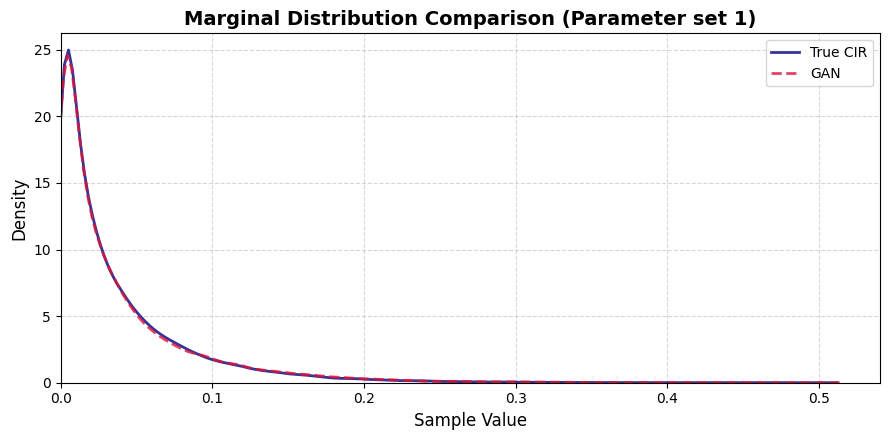


📌 Parameter set 1
    κ = 2.800   γ = 0.600   v̄ = 0.100    ν0 = 0.030   T = 1.000
    📏 Wasserstein distance: 0.0005


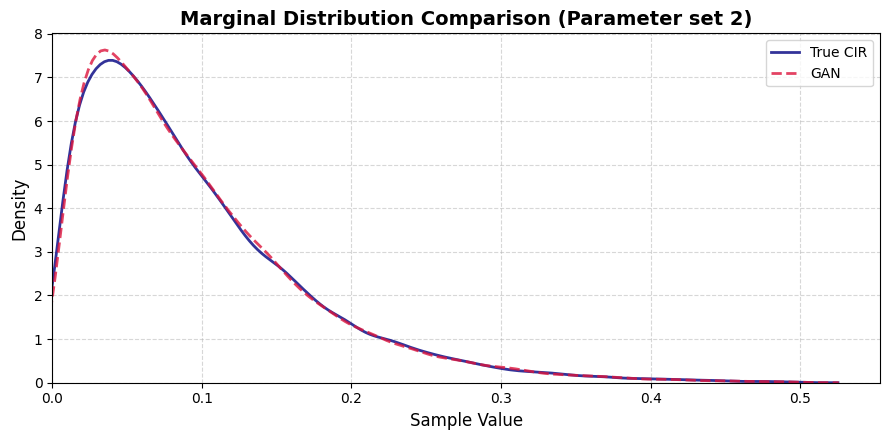


📌 Parameter set 2
    κ = 3.500   γ = 0.700   v̄ = 0.110    ν0 = 0.040   T = 0.300
    📏 Wasserstein distance: 0.0007


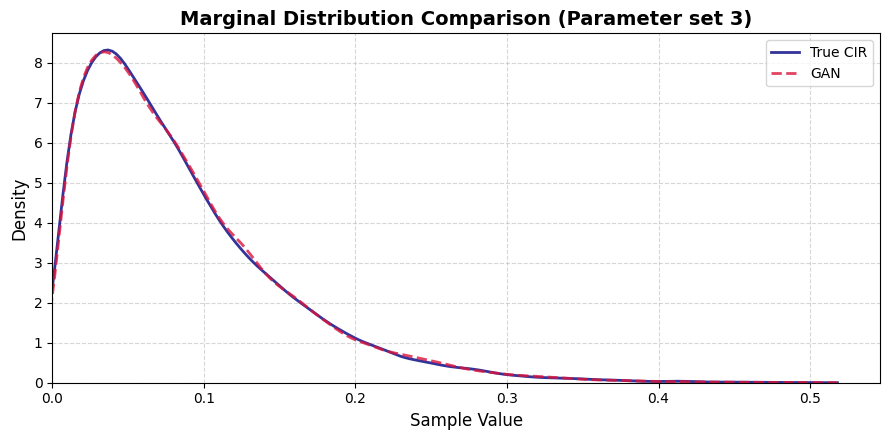


📌 Parameter set 3
    κ = 1.900   γ = 0.450   v̄ = 0.070    ν0 = 0.050   T = 0.750
    📏 Wasserstein distance: 0.0009


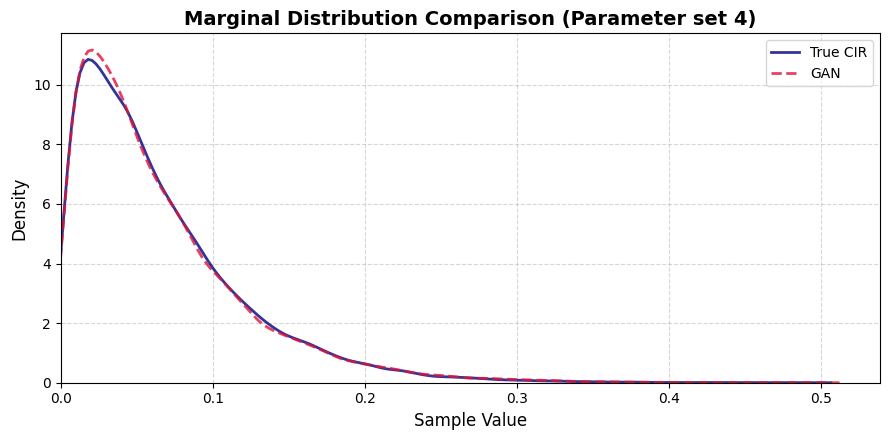


📌 Parameter set 4
    κ = 2.500   γ = 0.500   v̄ = 0.090    ν0 = 0.080   T = 0.900
    📏 Wasserstein distance: 0.0015


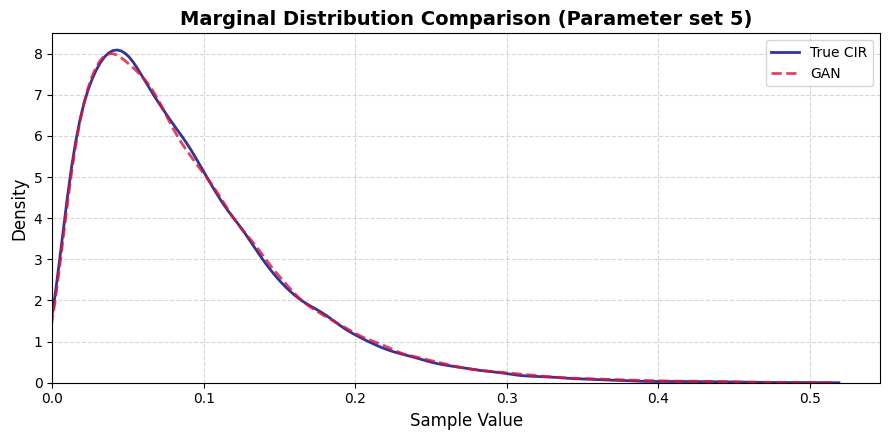


📌 Parameter set 5
    κ = 3.200   γ = 0.650   v̄ = 0.110    ν0 = 0.100   T = 0.600
    📏 Wasserstein distance: 0.0004


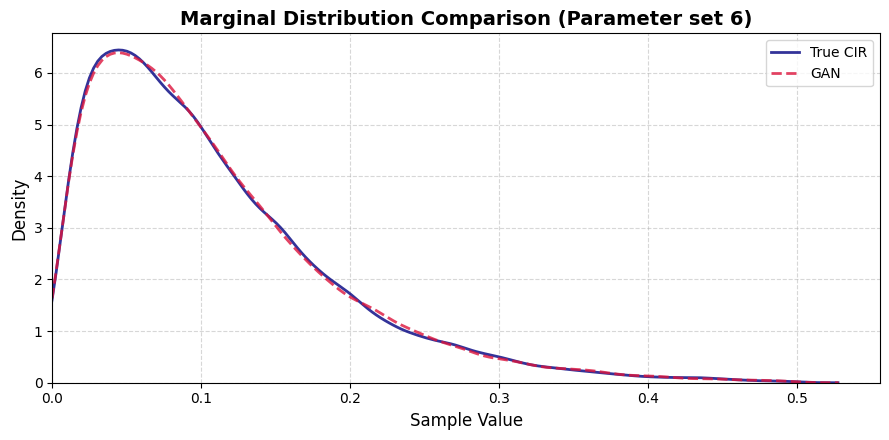

In [10]:
import torch

# Paramètres de configuration


# Cas typiques calibrés (kappa, gamma, v̄, rho, v0, T)
# Feller ratio = 4 * kappa * v̄ / gamma²
typical_params = torch.tensor([
    [1.5, 0.55, 0.06, 0.01, 0.5],   # ratio ≈ 1.19, proche du seuil
    [2.8, 0.60, 0.10, 0.03, 1.0],   # ratio ≈ 3.11
    [3.5, 0.70, 0.11, 0.04, 0.3],   # ratio ≈ 3.14
    [1.9, 0.45, 0.07,  0.05, 0.75],  # ratio ≈ 2.63
    [2.5, 0.50, 0.09, 0.08, 0.9],   # ratio ≈ 3.60
    [3.2, 0.65, 0.11,  0.1, 0.6],   # ratio ≈ 3.33
], dtype=__dtype__, device=__device__)

# Fonction pour calculer le ratio de Feller
def compute_feller_ratio(kappa, gamma, vbar):
    return (4 * kappa * vbar) / (gamma ** 2)

# Affichage des ratios de Feller
for i, row in enumerate(typical_params):
    kappa, gamma, vbar = row[0], row[1], row[2]
    ratio = compute_feller_ratio(kappa, gamma, vbar)
    print(f"Sample {i+1}: Feller ratio ≈ {ratio.item():.2f}")

# Test marginal sur ces cas typiques
show_marginal(
    model,
    dataset=typical_params,
    cap=0.5,
    dtype=__dtype__,
    device=__device__,
)


### Vectorized evaluation of KS and Wasserstein distances

The function `evaluate_distributional_distance_vectorized_KS_Wass` evaluates the distributional discrepancy between a trained generator and a reference simulator over a collection of parameter configurations.

For each parameter set, the method generates $N_{\text{traj}}$ independent samples from:
- the reference process, producing $S^{\text{true}}$,
- the generator, producing $S^{\text{model}}$.

An optional post-processing map can be applied to both outputs, and values are clipped to a fixed cap for numerical stability.

---

### 1-Wasserstein distance

For each parameter set, the 1-Wasserstein distance is approximated by sorting the samples and computing the average absolute deviation:

$$
W_1
=
\frac{1}{N_{\text{traj}}}
\sum_{j=1}^{N_{\text{traj}}}
\big| S^{\text{true}}_{(j)} - S^{\text{model}}_{(j)} \big|.
$$

---

### Kolmogorov–Smirnov distance

The Kolmogorov–Smirnov distance is estimated by building histogram-based empirical CDFs on $[0,\text{cap}]$ and taking the maximum absolute gap:

$$
\mathrm{KS}
=
\sup_x
\big| F^{\text{true}}(x) - F^{\text{model}}(x) \big|.
$$

---

### Aggregation

The function computes KS and Wasserstein distances for each parameter set and returns global summary statistics across the tested parameter space:
- mean,
- standard deviation,
- worst-case value.

These metrics provide a compact quantitative assessment of distributional fidelity of the generator relative to the benchmark simulator.


In [11]:
import torch

def evaluate_distributional_distance_vectorized_KS_Wass(model,
                                                         param_tensor: torch.Tensor,
                                                         N_traj: int = 10000,
                                                         batch_size: int = 512,
                                                         noise_size: int = 5,
                                                         cap: float = 5.0,
                                                         device: str = "cuda",
                                                         dtype: torch.dtype = torch.float32,
                                                         multi_gpu: bool = True,
                                                         reference_process=None,
                                                         postprocess=None,
                                                         dt: float = 0.001):
    """
    Evaluate distributional distance (KS and Wasserstein-1) between a generative model
    and a reference process, for a set of input parameters.

    Args:
        model (torch.nn.Module): Generative model.
        param_tensor (torch.Tensor): Parameters to test, shape (N_param, d).
        N_traj (int): Number of trajectories per parameter.
        batch_size (int): Batch size.
        noise_size (int): Dimension of latent noise.
        cap (float): Upper cap for post-processed values.
        device (str): Device string.
        dtype (torch.dtype): Data type.
        multi_gpu (bool): Whether to use DataParallel.
        reference_process (callable): Callable reference process.
        postprocess (callable): Optional postprocessing function.
        dt (float): Time step for reference process.
    Returns:
        dict: KS and Wasserstein-1 distances.
    """
    assert reference_process is not None, "A reference process must be provided."
    device = torch.device(device)
    param_tensor = param_tensor.to(dtype=dtype, device=device)
    model = model.to(device).eval()

    if multi_gpu and torch.cuda.device_count() > 1:
        model = torch.nn.DataParallel(model)

    N_param = param_tensor.size(0)

    ks_list, wass_list = [], []

    for i in range(0, N_param, batch_size):
        p_batch = param_tensor[i:i + batch_size]
        B = p_batch.size(0)

        p_expanded = p_batch.unsqueeze(1).expand(B, N_traj, -1).reshape(B * N_traj, -1)

        with torch.no_grad():
            columns = [p_batch[:, j].repeat_interleave(N_traj).to(device) for j in range(p_batch.shape[1])]
            raw_true = reference_process(*columns, dtype=dtype, device=device)

            if postprocess is not None:
                S_true = postprocess(raw_true.view(-1), p_batch, N_traj).clamp(1e-5, cap)
            else:
                S_true = raw_true.view(B, N_traj).clamp(1e-5, cap)

            noise = torch.rand(B * N_traj, noise_size, dtype=dtype, device=device)
            input_tensor = torch.cat([noise, p_expanded], dim=1)
            raw_output = model(input_tensor).view(B * N_traj)

            if postprocess is not None:
                S_model = postprocess(raw_output, p_batch, N_traj).clamp(1e-5, cap)
            else:
                S_model = raw_output.view(B, N_traj).clamp(1e-5, cap)

        # Wasserstein-1 distance
        sorted_true, _ = torch.sort(S_true, dim=1)
        sorted_model, _ = torch.sort(S_model, dim=1)
        wass1 = torch.mean(torch.abs(sorted_true - sorted_model), dim=1)
        wass_list.append(wass1.cpu())

        # KS distance
        hist_true = torch.stack([torch.histc(x, bins=1000, min=0, max=cap) for x in S_true])
        hist_model = torch.stack([torch.histc(x, bins=1000, min=0, max=cap) for x in S_model])
        ecdf_true = torch.cumsum(hist_true, dim=1) / N_traj
        ecdf_model = torch.cumsum(hist_model, dim=1) / N_traj
        ks, _ = torch.max(torch.abs(ecdf_true - ecdf_model), dim=1)
        ks_list.append(ks.cpu())

    ks_all = torch.cat(ks_list)
    wass_all = torch.cat(wass_list)

    final = {
        "ks_distance_mean": ks_all.mean().item(),
        "ks_distance_std": ks_all.std().item(),
        "ks_distance_worst": ks_all.max().item(),
        "wasserstein_1_mean": wass_all.mean().item(),
        "wasserstein_1_std": wass_all.std().item(),
        "wasserstein_1_worst": wass_all.max().item(),
    }

    return final


### Distributional evaluation over random CIR parameters

This experiment evaluates the distributional accuracy of the trained generator over randomly sampled parameter configurations for the Cox–Ingersoll–Ross (CIR) variance process.

Parameter vectors are generated within the prescribed training ranges for $\kappa$, $\gamma$, $\bar v$, $v_0$, and $T$, with an additional constraint on the Feller ratio. For each configuration, the model distribution is compared to the benchmark CIR simulator using moment errors and distributional distances. All metrics are aggregated into a summary table reporting mean, standard deviation, and worst-case statistics across the parameter space.

---

### ⚠️ Important note on experimental scale

The results reported in the associated paper are obtained using large-scale experiments with:
- $n_{\text{simu}} = 100\,000$ parameter configurations,
- $N_{\text{traj}} = 100\,000$ samples per configuration.

In this notebook, we deliberately use reduced values $n_{\text{simu}} = 100$ and $N_{\text{traj}} = 10\,000$ to ensure that the code can run on standard hardware within a reasonable execution time.

These reduced settings are intended for demonstration and reproducibility only and should not be interpreted as the final quantitative results reported in the paper.

---

### Output

The summary table is exported to CSV and LaTeX formats for direct inclusion in reports and manuscripts.


In [12]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

# 📌 CIR parameters: same ranges as Heston, except without rho
params = {
    "nb_simu": 100,
    "log_model": True,           # Enable log-model if required
    "KAPPAS": [1.0, 4.0],
    "GAMMAS": [0.1, 0.75],
    "VBARS": [0.01, 0.15],
    "v0": [0.01, 0.1],
    "T": [0.25, 1.0],
    "dt": 0.001,
    "cap": 0.6,
    "dtype": torch.float32,
    "device": torch.device("cuda:0"),
    "feller_ratio": [0.4, 10.0]
}

# ✅ Example: generate CIR parameter samples
D = CIR_param(random_param=True, **params).params

# ✅ Evaluate the model using the simplified evaluation pipeline
results = evaluate_distributional_distance_vectorized_KS_Wass(
    model,
    D,
    N_traj=10_00,
    batch_size=8,
    device="cuda",
    multi_gpu=True,
    reference_process=CIR,
    postprocess=None  # or CIR_postprocess if available
)

# ✅ Build a clean formatted results table
table = []

for metric, value in results.items():
    if metric.endswith("_mean"):
        base = metric[:-5]
        std_key = base + "_std"
        worst_key = base + "_worst"
        std_val = results.get(std_key, None)
        worst_val = results.get(worst_key, None)

        table.append({
            "Metric": base,
            "Mean": value,
            "Worst case": worst_val,
            "Std": std_val
        })

# 📊 Build DataFrame
df = pd.DataFrame(table)
df = df[["Metric", "Mean", "Worst case", "Std"]]
df.set_index("Metric", inplace=True)
df = df.round(6)

# ✅ Pretty display
print("📊 CIR Model – Distributional Distance Summary:")
display(
    df.style
      .set_caption("CIR model – KS and Wasserstein-1 Distances")
      .format(precision=3)
      .background_gradient(subset=["Mean"], cmap="Blues", low=0.2, high=0.6)
)



/usr/local/lib/python3.11/dist-packages/torch/nn/modules/linear.py:116: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return F.linear(input, self.weight, self.bias)


📊 CIR Model – Distributional Distance Summary:


,Mean,Worst case,Std
Metric,,,
ks_distance,0.036,0.075,0.011
wasserstein_1,0.003,0.007,0.002
